#Aim:
To understand:

* Logistic Regression
* Binary Classification
* Accuracy
* Confusion Matrix
* Precision & Recall
* Healthcare ML Applications
* Real-world prediction systems



**IMPORTING DATASET**

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


**IMPORTING LIBRARIES**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**LOADING DATASET**

In [34]:
df = pd.read_csv(path+'/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**UNDERSTANDING  DATASET**

In [35]:
#Data Shape
df.shape

(768, 9)

In [36]:
#Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
#Null count
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**CHECK TARGET VARIABLE**

In [38]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


**VISUALISING DATA DISTRIBUTION**

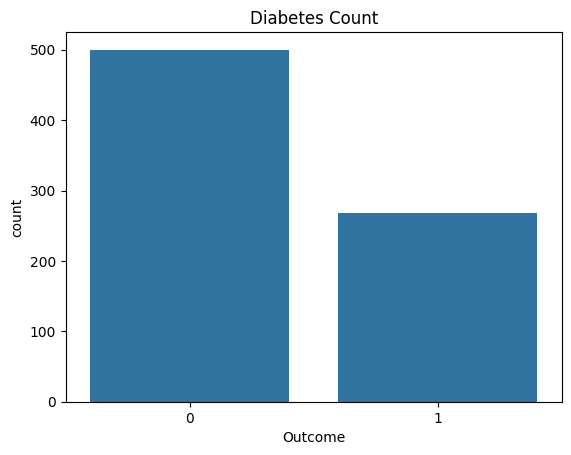

In [39]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Count")
plt.savefig('Diabetes Count', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

**FEATURES AND TARGET**

In [40]:
X = df.drop("Outcome", axis=1)
y = df['Outcome']

**TRAIN-TEST SPLIT**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**FEATURE SCALING**

In [42]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**CREATE LOGISTIC REGRESSION MODEL**

In [43]:
model = LogisticRegression()

**TRAIN MODEL**

In [44]:
model.fit(X_train, y_train)

LogisticRegression()

**MAKE PREDICTIONS**

In [45]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 1 1 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


**ACCURACY SCORE**

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


**CONFUSION MATRIX**

In [47]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[79 20]
 [18 37]]


**VISUALISE CONFUSION MATRIX**

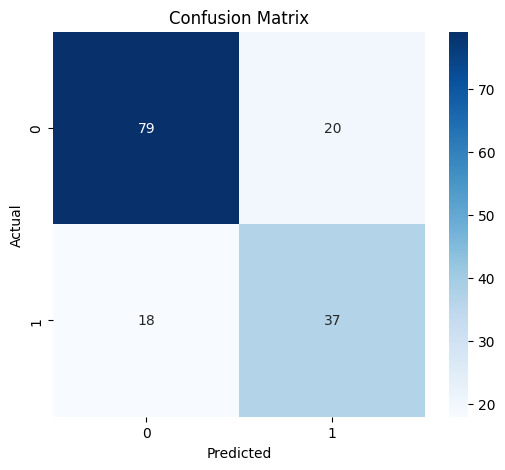

In [48]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()


**CLASSIFCATION REPORT**

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



**PREDICT NEW PATIENT**

In [50]:
new_patient = [[2, 120, 70, 20, 79, 25.0, 0.5, 33]]

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**PROBABILITY PREDICTION**

In [52]:
probability = model.predict_proba(new_patient)

print(probability)

[[0.84677483 0.15322517]]


**FEATURE IMPORTANCE UNDERSTANDING**

In [54]:
features =X.columns

coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

print(importance_df)

                    Feature  Coefficient
0               Pregnancies     0.212554
1                   Glucose     1.071301
2             BloodPressure    -0.247826
3             SkinThickness     0.045729
4                   Insulin    -0.200783
5                       BMI     0.778182
6  DiabetesPedigreeFunction     0.230625
7                       Age     0.421207
